# Logistic Regression - Learning Notes

> **Created for ML learning journey** 📚

## 1. What is Logistic Regression?

Logistic Regression is a **classification algorithm** used to predict the probability that an input belongs to a particular category (class).

Despite its name containing "regression," it is **not** used for predicting continuous values like house prices. Instead, it solves **classification problems** such as:

- Email: Spam or Not Spam?
- Tumor: Malignant or Benign?
- Loan: Default or Not Default?

## 2. Why Not Use Linear Regression?

If we use linear regression for classification:
- The predicted value can be **any real number** (e.g., -200, 500).
- Classification needs output between **0 and 1** (probability).
- Linear regression is sensitive to outliers in classification tasks.

**Solution:** Use the **Sigmoid Function** to squeeze any value into the range (0, 1).

## 3. The Sigmoid (Logistic) Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where:
- $z = w^T x + b$ (linear combination of features)
- $e$ is Euler's number (~2.718)

**Properties:**
- If $z \to +\infty$, $\sigma(z) \to 1$
- If $z \to -\infty$, $\sigma(z) \to 0$
- If $z = 0$, $\sigma(z) = 0.5$

### Let's plot the Sigmoid Function

Matplotlib is building the font cache; this may take a moment.


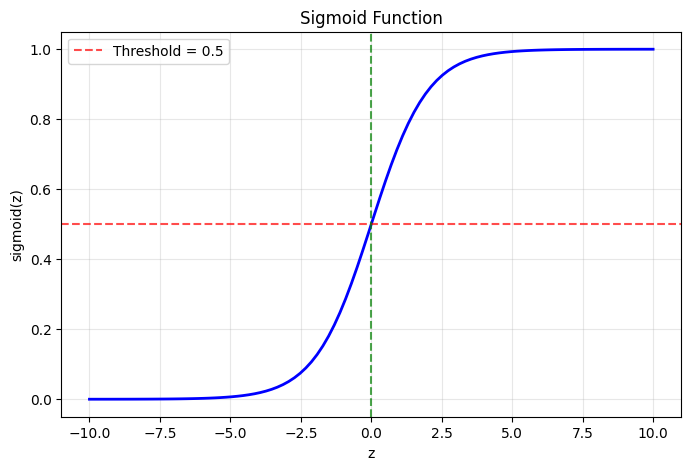

sigmoid(0) = 0.5000
sigmoid(5) = 0.9933
sigmoid(-5) = 0.0067


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Create values from -10 to 10
z = np.linspace(-10, 10, 100)
sigma_z = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, sigma_z, linewidth=2, color="blue")
plt.axhline(y=0.5, color="red", linestyle="--", alpha=0.7, label="Threshold = 0.5")
plt.axvline(x=0, color="green", linestyle="--", alpha=0.7)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"sigmoid(0) = {sigmoid(0):.4f}")
print(f"sigmoid(5) = {sigmoid(5):.4f}")
print(f"sigmoid(-5) = {sigmoid(-5):.4f}")

## 4. Decision Boundary

After getting the probability $\hat{y}$:

$$\hat{y} =\begin{cases}1 & \text{if } \sigma(z) \geq 0.5 \\0 & \text{if } \sigma(z) < 0.5\end{cases}$$

The value **0.5** is called the **decision threshold**. You can adjust it based on your problem.

## 5. Cost Function (Log Loss)

Using Mean Squared Error (MSE) for logistic regression makes the cost function **non-convex**.

Instead, we use **Log Loss** (Cross-Entropy Loss):

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

**Intuition:**
- If $y = 1$ and $\hat{y} \approx 1$ -> cost is near 0 ✓
- If $y = 1$ and $\hat{y} \approx 0$ -> cost is very high ✗

## 6. Gradient Descent

$$w := w - \alpha \frac{\partial J}{\partial w}$$

$$b := b - \alpha \frac{\partial J}{\partial b}$$

Where $\alpha$ is the **learning rate**.

The derivatives are surprisingly similar to linear regression:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) x^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

## 7. Practical Example in Python

Let's train a logistic regression model using scikit-learn.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Generate sample data
X, y = make_classification(n_samples=1000, n_features=4, n_classes=2, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)

# Results
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.89

Confusion Matrix:
[[92  9]
 [14 85]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       101
           1       0.90      0.86      0.88        99

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200



## 8. Key Takeaways

| Concept | Summary |
|---------|---------|
| **Purpose** | Binary classification |
| **Output** | Probability (0 to 1) |
| **Key Function** | Sigmoid |
| **Loss Function** | Log Loss / Cross-Entropy |
| **When to use** | Linearly separable data, baseline model |

> **Tip:** Logistic regression is often the **first algorithm** you should try for any binary classification problem!

## 9. Exercise for You 📝

Try to:
1. Load the famous **Iris dataset** (but use only 2 classes for binary classification)
2. Train a logistic regression model
3. Plot the decision boundary
4. Try changing the decision threshold (e.g., 0.3 or 0.7) and see what happens

---

## 📝 My Personal Notes

*Add your own notes, questions, and discoveries here as you learn!*

- 
- 
- 